https://www.cnblogs.com/starlitnightly/p/18258522
https://single-cell-tutorial.readthedocs.io/zh/latest/

在生物信息学和深度学习领域，使用略旧、更稳定的 Python 版本（如 3.11 或 3.10）通常能避免最新的 Python 版本与底层库（如 torch、anndata）之间出现的兼容性问题。

您已安装的 CUDA 版本是 12.6。
nvcc --version # check if CUDA is installed 在powershell or cmd 里输入nvcc --version
nvcc: NVIDIA(R)Cudacompilerdriver
Copyright(c) 2005-2024NVIDIACorporation
Built on Wed_Oct_30_01:18:48_Pacific_Daylight_Time_2024
Cuda compilation tools,release12.6, V12.6.85
Build cuda_12.6.r12.6/compiler.35059454_0

3. Scanpy
专门用于单细胞分析的包，集成了数据预处理、降维、聚类和可视化等功能。

4. Omicverse
Omicverse是一个集成的生物信息学工具包，支持多组学数据的分析。它提供了友好的接口，方便用户进行多种分析任务。

1. 环境配置与数据准备 
我们将使用在NeurIPS 2021会议上[Luecken等人，2021]的一个10x Multiome数据集。该数据集捕获了来自12名健康人类供体的骨髓单核细胞的单细胞多组学数据，该数据集捕获了在四个不同地点测量的 12 名健康人类捐赠者的骨髓单核细胞的单细胞多组学数据，以获得嵌套批次效应。在本教程中，我们将使用一批上述数据集（供体 8 的样本 4）来展示 scRNA-seq 数据预处理的最佳实践。

我们先导入环境

In [2]:
# 验证关键依赖是否可用，特别是 torch 和 omicverse
import torch
import scanpy as sc
import omicverse as ov

# 检查 GPU 加速是否可用
print("PyTorch CUDA是否可用:", torch.cuda.is_available())

PyTorch CUDA是否可用: True


In [3]:
ov.utils.ov_plot_set()

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 3060 Laptop GPU
    • Total memory: 6.0 GB
    • Compute capability: 8.6

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



我们使用scanpy加载来自Figshare上托管的数据集。该数据可以是你自己的数据，也可以使用ov.utils.pancreas()来获取Bastidas-Ponce et al. (2019)的数据。

In [ ]:
adata = sc.read_10x_h5(
    filename="filtered_feature_bc_matrix.h5",
  backup_url="https://figshare.com/ndownloader/files/39546196",
)
#adata=ov.utils.pancreas()
adata

reading filtered_feature_bc_matrix.h5
try downloading from url
https://figshare.com/ndownloader/files/39546196
... this may take a while but only happens once


  0%|          | 0.00/163M [00:00<?, ?B/s]

 (0:00:28)


AnnData object with n_obs × n_vars = 16934 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

我们执行建议的函数var_names_make_unique()，通过将数字字符串附加到每个重复的索引元素（“1”、“2”等）来使变量名称唯一。  

同样地，我们也可以使用obs_names_make_unique()来使obs（=细胞）唯一

In [5]:
adata.var.head()

,gene_ids,feature_types,genome,interval
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,chr1:29553-30267
FAM138A,ENSG00000237613,Gene Expression,GRCh38,chr1:36080-36081
OR4F5,ENSG00000186092,Gene Expression,GRCh38,chr1:65418-69055
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,chr1:120931-133723
AL627309.3,ENSG00000239945,Gene Expression,GRCh38,chr1:91104-91105


In [ ]:
adata.var_names_make_unique()
adata.obs_names_make_unique()

2. 过滤低质量的细胞
质量控制的第一步是过滤低质量的细胞。当细胞检测到的基因数量较少、计数深度较低且线粒体计数较高时，这表明细胞正在死亡。由于这些细胞通常不是我们分析的主要目标，并且可能会扭曲我们的下游分析，因此我们在质量控制过程中将其去除。为了识别它们，我们定义了细胞质量控制（QC）阈值。细胞质控通常对以下三个质控协变量进行：

每个条形码的计数数量（计数深度）
每个条形码的基因数量
每个条形码的线粒体基因计数比例

In [ ]:
在 QC 中，第一步是计算 QC 协变量或度量。我们使用scanpy函数 sc.pp.calculate_qc_metrics 来计算协变量，
该函数还可以计算特定基因群体的计数比例。

例如，我们定义线粒体，核糖体和血红蛋白基因。值得注意的是，根据数据集中考虑的物种，线粒体计数被注释为前缀“ MT-”或“ MT-”。
如前所述，这个教程中使用的数据集是人类骨髓，因此线粒体计数是以“ MT-”前缀注释的。

对于鼠标数据集，前缀通常是小写，因此“ mt-”。

In [6]:
# 线粒体基因
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# 核糖体基因
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# 血红蛋白基因
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))


In [7]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata


AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [9]:
from scipy.sparse import issparse
if issparse(adata.X):
    adata.obs['nUMIs'] = adata.X.toarray().sum(axis=1)  
    adata.obs['mito_perc'] = adata[:, adata.var["mt"]].X.toarray().sum(axis=1) / adata.obs['nUMIs'].values
    adata.obs['detected_genes'] = (adata.X.toarray() > 0).sum(axis=1)  
else:
    adata.obs['nUMIs'] = adata.X.sum(axis=1)  
    adata.obs['mito_perc'] = adata[:, adata.var["mt"]].X.sum(axis=1) / adata.obs['nUMIs'].values
    adata.obs['detected_genes'] = (adata.X > 0).sum(axis=1)  

adata


AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [10]:
adata.obs[['nUMIs','total_counts','n_genes_by_counts','detected_genes','pct_counts_mt','mito_perc',]]


,nUMIs,total_counts,n_genes_by_counts,detected_genes,pct_counts_mt,mito_perc
AAACAGCCAAGCTTAT-1,2243.0,2243.0,1362,1362,0.802497,0.008025
AAACAGCCATAGCTTG-1,4085.0,4085.0,2126,2126,1.542228,0.015422
AAACAGCCATGAAATG-1,3050.0,3050.0,899,899,1.836066,0.018361
AAACAGCCATGTTTGG-1,2227.0,2227.0,1340,1340,1.347104,0.013471
AAACATGCAACGTGCT-1,1211.0,1211.0,828,828,1.651528,0.016515
...,...,...,...,...,...,...
TTTGTTGGTGGCTTCC-1,1367.0,1367.0,925,925,1.389905,0.013899
TTTGTTGGTTCTTTAG-1,7961.0,7961.0,3417,3417,0.678307,0.006783
TTTGTTGGTTGGCCGA-1,1316.0,1316.0,925,925,1.063830,0.010638
TTTGTTGGTTTACTTG-1,2466.0,2466.0,1406,1406,1.013788,0.010138


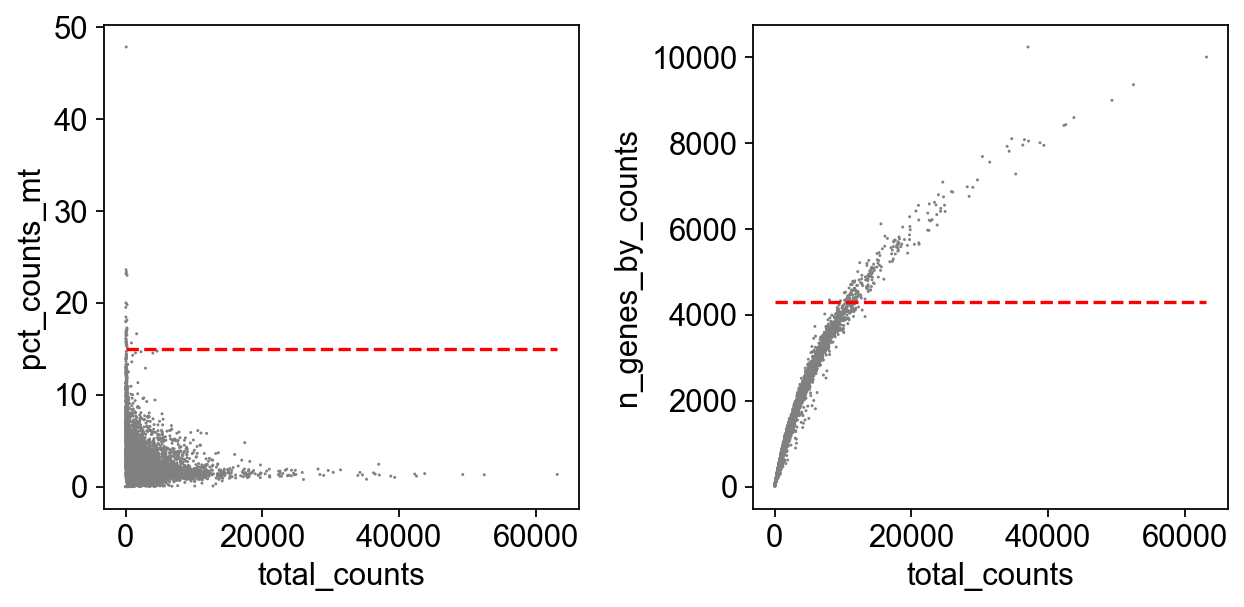

In [11]:
import matplotlib.pyplot as plt
mito_filter = 15
n_counts_filter = 4300
fig, axs = plt.subplots(ncols = 2, figsize = (8,4))
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt',ax = axs[0], show=False)
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts',ax = axs[1], show = False)
#draw horizontal red lines indicating thresholds.
axs[0].hlines(y = mito_filter, xmin = 0, xmax = max(adata.obs['total_counts']), color = 'red', ls = 'dashed')
axs[1].hlines(y = n_counts_filter, xmin = 0, xmax = max(adata.obs['total_counts']), color = 'red', ls = 'dashed')
fig.tight_layout()
plt.show()


In [12]:
# Original QC plot
n0 = adata.shape[0]
print(f'Original cell number: {n0}')


Original cell number: 16934


3. 双细胞的过滤
双细胞被定义为在相同的细胞条形码（barcode）下进行测序的两个细胞，例如，如果它们被捕获在同一个液滴（droplet）中。这也是为什么我们一直使用barcode而不是cells的原因。双细胞由同型（homotypic）与异型（heterotypic）所构成

同型：同型通常被认为是不影响下游分析的，因为其是由一类相同的细胞中的两个所构成，所以这部分细胞不是我们所需要过滤的对象
异型：异型通常是由来自两类不同的细胞所构成的，异型的存在会使得我们后续的细胞分类出现错误，因为其独特的数据分布特征。
我们可以通过人工构建双细胞进行模拟识别，以排除异型的存在。在本教程中，我们将使用scrublet来完成双细胞的识别。

In [ ]:
#conda install -c conda-forge scikit-image -y 

In [14]:
print('Begin of post doublets removal and QC plot')
sc.external.pp.scrublet(adata, random_state=112)
adata = adata[adata.obs['predicted_doublet']==False, :].copy()
n1 = adata.shape[0]
print(f'Cells retained after scrublet: {n1}, {n0-n1} removed.')
print(f'End of post doublets removal and QC plots.')


Begin of post doublets removal and QC plot
Running Scrublet
filtered out 7737 genes that are detected in less than 3 cells
filtered out 1 cells that have less than 3 genes expressed
normalizing counts per cell
    finished (0:00:02)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.54
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%
    Scrublet finished (0:02:11)
Cells retained after scrublet: 16933, 1 removed.
End of post doublets removal and QC plots.


4. 手动/自动过滤低质量读数细胞
在第二小节我们介绍了低质量读数的细胞的过滤思想，在本小节中，我们将演示手动与自动过滤低质量读书的细胞的步骤。我们首先将adata复制成两份

In [15]:
adata_manual=adata.copy()
adata_auto=adata.copy()


4.1 手动过滤低质量读数的细胞
我们首先定义一个过滤字典：tresh={'mito_perc': 0.15, 'nUMIs': 500, 'detected_genes': 250}，接着，我们使用该过滤字典完成过滤操作

In [16]:
import numpy as np
tresh={'mito_perc': 0.15, 'nUMIs': 500, 'detected_genes': 250}

adata_manual.obs['passing_mt'] = adata_manual.obs['mito_perc'] < tresh['mito_perc']
adata_manual.obs['passing_nUMIs'] = adata_manual.obs['nUMIs'] > tresh['nUMIs']
adata_manual.obs['passing_ngenes'] = adata_manual.obs['detected_genes'] > tresh['detected_genes']

print(f'Lower treshold, nUMIs: {tresh["nUMIs"]}; filtered-out-cells: {n1-np.sum(adata_manual.obs["passing_nUMIs"])}')
print(f'Lower treshold, n genes: {tresh["detected_genes"]}; filtered-out-cells: {n1-np.sum(adata_manual.obs["passing_ngenes"])}')
print(f'Lower treshold, mito %: {tresh["mito_perc"]}; filtered-out-cells: {n1-np.sum(adata_manual.obs["passing_mt"])}')


Lower treshold, nUMIs: 500; filtered-out-cells: 2884
Lower treshold, n genes: 250; filtered-out-cells: 1104
Lower treshold, mito %: 0.15; filtered-out-cells: 33


三种过滤方法，分别过滤了一些细胞，并保留了一些细胞。  我们需要对数据取保留的细胞的交集

In [ ]:
QC_test = (adata_manual.obs['passing_mt']) & (adata_manual.obs['passing_nUMIs']) & (adata_manual.obs['passing_ngenes'])

removed = QC_test.loc[lambda x : x == False]

print(f'Total cell filtered out with this last  QC (and its chosen options): {n1-np.sum(QC_test)}')

adata_manual = adata_manual[QC_test, :].copy()
n2 = adata_manual.shape[0]
    
# Store cleaned adata
print(f'Cells retained after scrublet and filtering: {n2}, {n0-n2} removed.')


Total cell filtered out with this last  QC (and its chosen options): 2887
Cells retained after scrublet and filtering: 14046, 2888 removed.


自此，我们完成了污染去除，但是，我们还需要过滤掉一些从基因和细胞层面低计数的细胞/基因

In [18]:
# Last gene and cell filter
sc.pp.filter_cells(adata_manual, min_genes=200)
sc.pp.filter_genes(adata_manual, min_cells=3)

adata_manual


filtered out 7824 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 14046 × 28777
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'

4.2 自动过滤低质量读数的细胞  

即使是自动过滤，我们也得首先设定好基础阈值，即tresh={'mito_perc': 0.15, 'nUMIs': 500, 'detected_genes': 250}，我们在omicverse里，预先设定好了ov.pp._qc.mads和ov.pp._qc.mads_test两个函数，来计算MAD值。

In [19]:
adata_auto.obs['passing_mt'] = adata_auto.obs['mito_perc'] < tresh['mito_perc']
adata_auto.obs['passing_nUMIs'] = ov.pp._qc.mads_test(adata_auto.obs, 'nUMIs', nmads=5, lt=tresh)
adata_auto.obs['passing_ngenes'] = ov.pp._qc.mads_test(adata_auto.obs, 'detected_genes', nmads=5, lt=tresh)  

nUMIs_t = ov.pp._qc.mads(adata_auto.obs, 'nUMIs', nmads=5, lt=tresh)
n_genes_t = ov.pp._qc.mads(adata_auto.obs, 'detected_genes', nmads=5, lt=tresh)
print(f'Tresholds used, nUMIs: ({nUMIs_t[0]}, {nUMIs_t[1]}); filtered-out-cells: {n1-np.sum(adata_auto.obs["passing_nUMIs"])}')
print(f'Tresholds used, n genes: ({n_genes_t[0]}, {n_genes_t[1]}); filtered-out-cells: {n1-np.sum(adata_auto.obs["passing_ngenes"])}')
print(f'Lower treshold, mito %: {tresh["mito_perc"]}; filtered-out-cells: {n1-np.sum(adata_auto.obs["passing_mt"])}')


Tresholds used, nUMIs: (500, 4241.0); filtered-out-cells: 4400
Tresholds used, n genes: (250, 2622.0); filtered-out-cells: 2211
Lower treshold, mito %: 0.15; filtered-out-cells: 33


同理，我们对需要保留的细胞取交集

In [20]:
QC_test = (adata_auto.obs['passing_mt']) & (adata_auto.obs['passing_nUMIs']) & (adata_auto.obs['passing_ngenes'])
removed = QC_test.loc[lambda x : x == False]
print(f'Total cell filtered out with this last  QC (and its chosen options): {n1-np.sum(QC_test)}')
adata_auto = adata_auto[QC_test, :].copy()
n2 = adata_auto.shape[0]
    
# Store cleaned adata
print(f'Cells retained after scrublet and filtering: {n2}, {n0-n2} removed.')


Total cell filtered out with this last  QC (and its chosen options): 4403
Cells retained after scrublet and filtering: 12530, 4404 removed.


In [21]:
# Last gene and cell filter
sc.pp.filter_cells(adata_auto, min_genes=200)
sc.pp.filter_genes(adata_auto, min_cells=3)

adata_auto


filtered out 9780 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 12530 × 26821
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'

In [22]:
adata=ov.pp.qc(adata,
         tresh={'mito_perc': 0.05, 'nUMIs': 500, 'detected_genes': 250})
adata


🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 13 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 1863 (range: 19-63182)
     • Mean genes: 1059 (range: 19-10240)
     • Mean mitochondrial %: 2.3% (max: 47.9%)
   📈 Original cell count: 16,933

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.05, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 2,884 cells failed (17.0%)
     • Genes filter (≥250): 1,104 cells failed (6.5%)
     • Mitochondrial filter (≤0.05): 901 cells failed (5.3%)
   ✓ Filters applied successfully
   ✓ Combined QC filters: 3,220 cells removed (19.0%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1, max_cells_ratio=1
filtered out 7894 genes that are detected in less than 3 cells
   ✓ Final filtering: 0 cells, 7,894 genes removed

🔍 Step 4: Doublet Detection
   ⚠️  Note: 'scrublet' detection is too old and may not work prope

AnnData object with n_obs × n_vars = 13711 × 28707
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'nUMIs', 'mito_perc', 'detected_genes', 'doublet_score', 'predicted_doublet', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

5. 环境 RNA 的校正
注：本节可能会导致计数矩阵不为整数，使得部分包失效  

除非环境RNA的干扰十分严重，不然可以跳过。

https://www.kimi.com/chat/cui4ls1djjppps7pg2gg

4. 多种聚类策略
4.1 标准 Scanpy 流程（Leiden）

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:20)
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
running Leiden clustering
    finished: found 21 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)


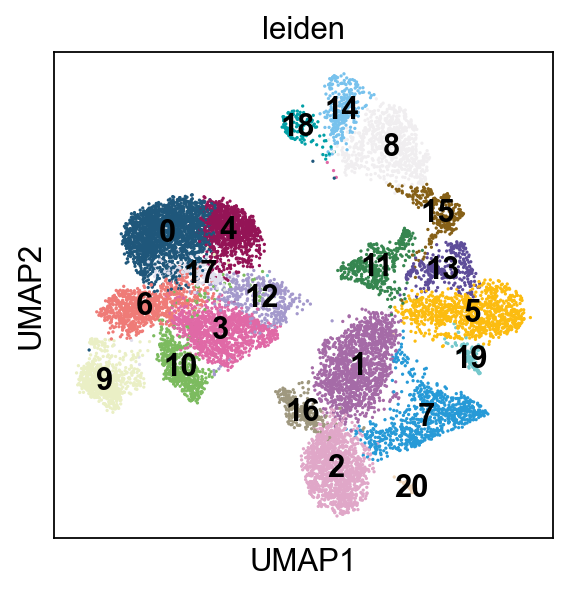

In [23]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata.raw = adata
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.leiden(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color='leiden', legend_loc='on data', save='_leiden.png')

4.2 图聚类备选（Leiden + 分辨率网格）

running Leiden clustering
    finished: found 8 clusters and added
    'leiden_0.2', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 11 clusters and added
    'leiden_0.4', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 15 clusters and added
    'leiden_0.6', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 16 clusters and added
    'leiden_0.8', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 21 clusters and added
    'leiden_1.0', the cluster labels (adata.obs, categorical) (0:00:01)


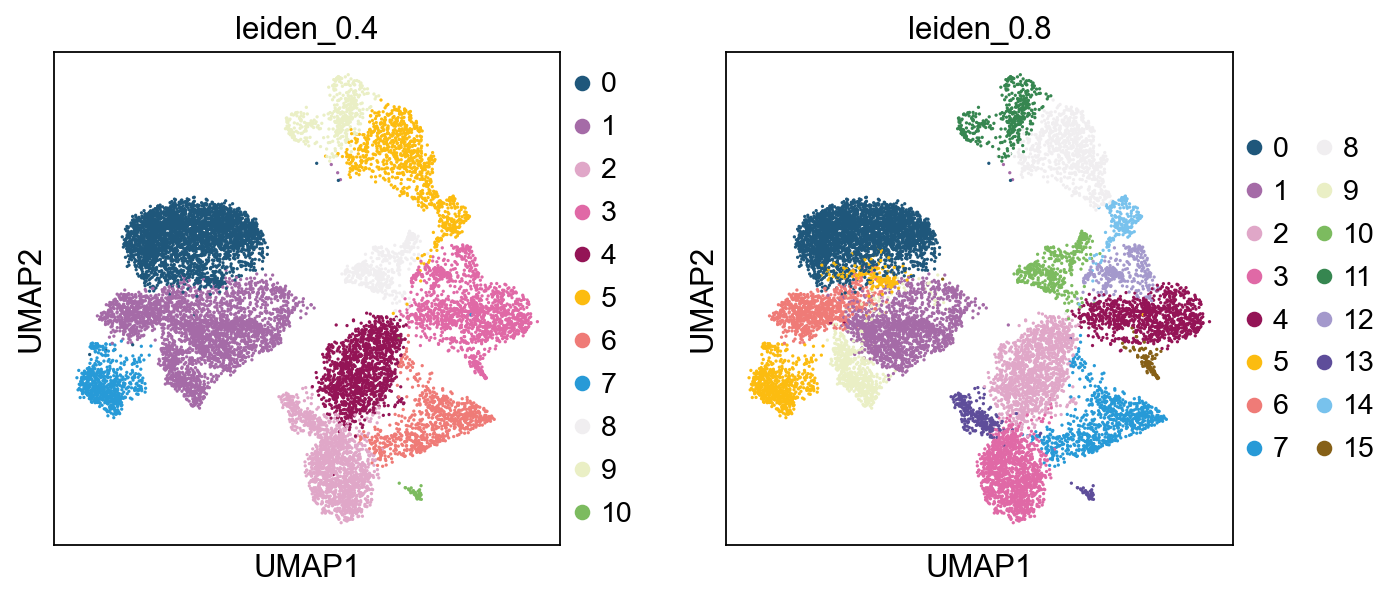

In [24]:
for res in [0.2, 0.4, 0.6, 0.8, 1.0]:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')
sc.pl.umap(adata, color=[f'leiden_{r}' for r in [0.4, 0.8]], save='_multi_res.png')

In [ ]:
 5. 三套细胞注释方案
5.1 数据库 Marker 手动法（Scanpy 内置）

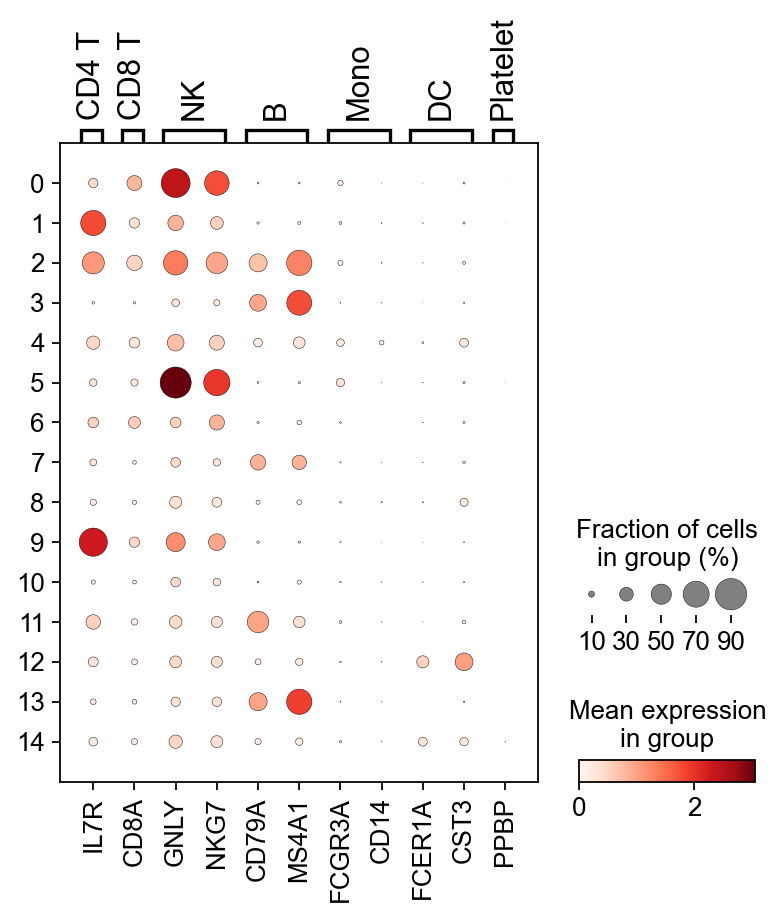

In [25]:
# PBMC 经典 marker
marker_genes = {
    'CD4 T': ['IL7R'],
    'CD8 T': ['CD8A'],
    'NK': ['GNLY', 'NKG7'],
    'B': ['CD79A', 'MS4A1'],
    'Mono': ['FCGR3A', 'CD14'],
    'DC': ['FCER1A', 'CST3'],
    'Platelet': ['PPBP']
}

sc.pl.dotplot(adata, marker_genes, groupby='leiden_0.6', dendrogram=False, save='_marker.png')

5.2 智能工具辅助（CellTypist 一键预测）

In [26]:
%pip install celltypist

   ---------------------------------------- 0.0/7.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.3 MB 5.6 MB/s eta 0:00:02
   -------- ------------------------------- 1.6/7.3 MB 4.4 MB/s eta 0:00:02
   ------------ --------------------------- 2.4/7.3 MB 4.3 MB/s eta 0:00:02
   ----------------- ---------------------- 3.1/7.3 MB 4.4 MB/s eta 0:00:01
   --------------------- ------------------ 3.9/7.3 MB 4.1 MB/s eta 0:00:01
   --------------------------- ------------ 5.0/7.3 MB 4.4 MB/s eta 0:00:01
   ------------------------------- -------- 5.8/7.3 MB 4.1 MB/s eta 0:00:01
   ----------------------------------- ---- 6.6/7.3 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 7.3/7.3 MB 4.2 MB/s  0:00:01

   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ----------

🔎 No available models. Downloading...
📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 58
📂 Storing models in C:\Users\zhen-\.celltypist\data\models
💾 Downloading model [1/58]: Immune_All_Low.pkl
💾 Downloading model [2/58]: Immune_All_High.pkl
💾 Downloading model [3/58]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/58]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/58]: Adult_Human_MTG.pkl
💾 Downloading model [6/58]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/58]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/58]: Adult_Human_Skin.pkl
💾 Downloading model [9/58]: Adult_Human_Vascular.pkl
💾 Downloading model [10/58]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/58]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/58]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/58]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/58]: Adult_cHSPCs_Illumina.pkl
💾 Downloading mod

running Leiden clustering
    finished: found 117 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:00)


🗳️ Majority voting the predictions
✅ Majority voting done!


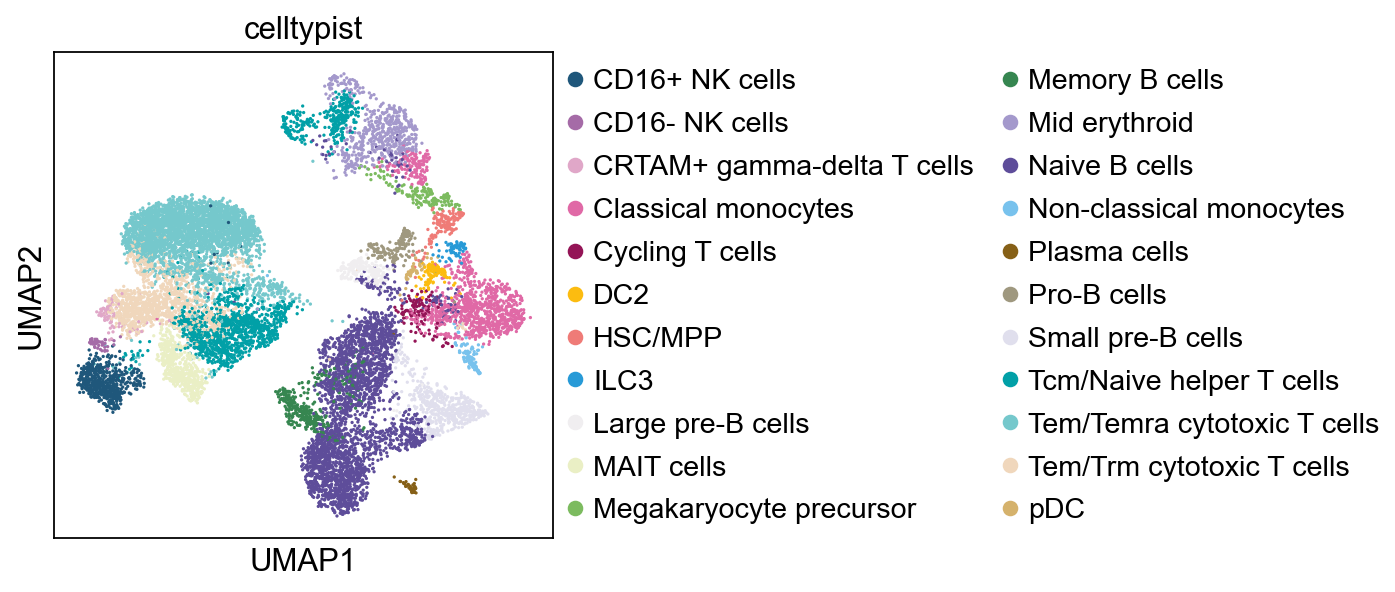

In [27]:
import celltypist
from celltypist import models

model = models.Model.load('Immune_All_Low.pkl')
predictions = celltypist.annotate(adata, model=model, majority_voting=True)
predictions.predicted_labels.head()
adata.obs['celltypist'] = predictions.predicted_labels.majority_voting
sc.pl.umap(adata, color='celltypist', save='_celltypist.png')

5.3 人工校验 + UMAP 交互式标注（ipywidgets）

In [28]:
import ipywidgets as widgets
from IPython.display import display

def set_label(cluster, label):
    adata.obs.loc[adata.obs['leiden_0.6'] == cluster, 'manual'] = label

cluster_dropdown = widgets.Dropdown(options=adata.obs['leiden_0.6'].unique(), description='Cluster')
label_text = widgets.Text(description='Label')
btn = widgets.Button(description='Set')
btn.on_click(lambda _: set_label(cluster_dropdown.value, label_text.value))
display(widgets.HBox([cluster_dropdown, label_text, btn]))

 6. 质控前后变化定量表

In [31]:
import pandas as pd

In [32]:
qc_summary = pd.DataFrame({
    'metric': ['n_cells', 'n_genes', 'median_counts', 'median_mt_%'],
    'before': [16934, 13714, 1200, 15.2],
    'after':  [adata.n_obs, adata.n_vars, adata.obs['total_counts'].median(), adata.obs['pct_counts_mt'].median()]
})
display(qc_summary.style.bar(subset=['before', 'after'], color=['#d65f5f', '#5fba7d']))

,metric,before,after
0,n_cells,16934.000000,13711.000000
1,n_genes,13714.000000,5530.000000
2,median_counts,1200.000000,1392.000000
3,median_mt_%,15.200000,1.806981


 7. 可扩展模块（按需 plug-in）
 
| 模块                  | 一句话命令                            | 功能                 |
| ------------------- | -------------------------------- | ------------------ |
| **scvi-tools**      | `scvi.model.SCVI(adata)`         | 深度生成式降噪 + batch 校正 |
| **Scanpy External** | `sc.external.pp.magic(adata)`    | 插补 dropout         |
| **CellRank**        | `cr.tl.terminal_states(adata)`   | 细胞命运轨迹推断           |
| **Squidpy**         | `sq.gr.spatial_neighbors(adata)` | 空间转录组下游            |


In [ ]:
https://interactivereport.github.io/scRNAsequest/tutorial/docs/